In [2]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter

2025-06-25 11:20:02.046499: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 11:20:02.066261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750843202.085083  259560 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750843202.091475  259560 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750843202.112599  259560 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
notebook_dir = os.getcwd()
in_the_wild_data_dir = os.path.join(notebook_dir, 'processed_imgs')
img_path = os.path.join(in_the_wild_data_dir, 'g', 'aug_0_g.c5d10b6f-5018-11f0-bd4e-4c034ff581fa.jpg')

img_ex = cv2.imread(img_path)

In [71]:
dataset_raw = tf.keras.utils.image_dataset_from_directory(
    in_the_wild_data_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    seed=1234
)

data_iterator = dataset_raw.as_numpy_iterator()
data_iterator

Found 750 files belonging to 24 classes.


NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7fb1202908e0>)

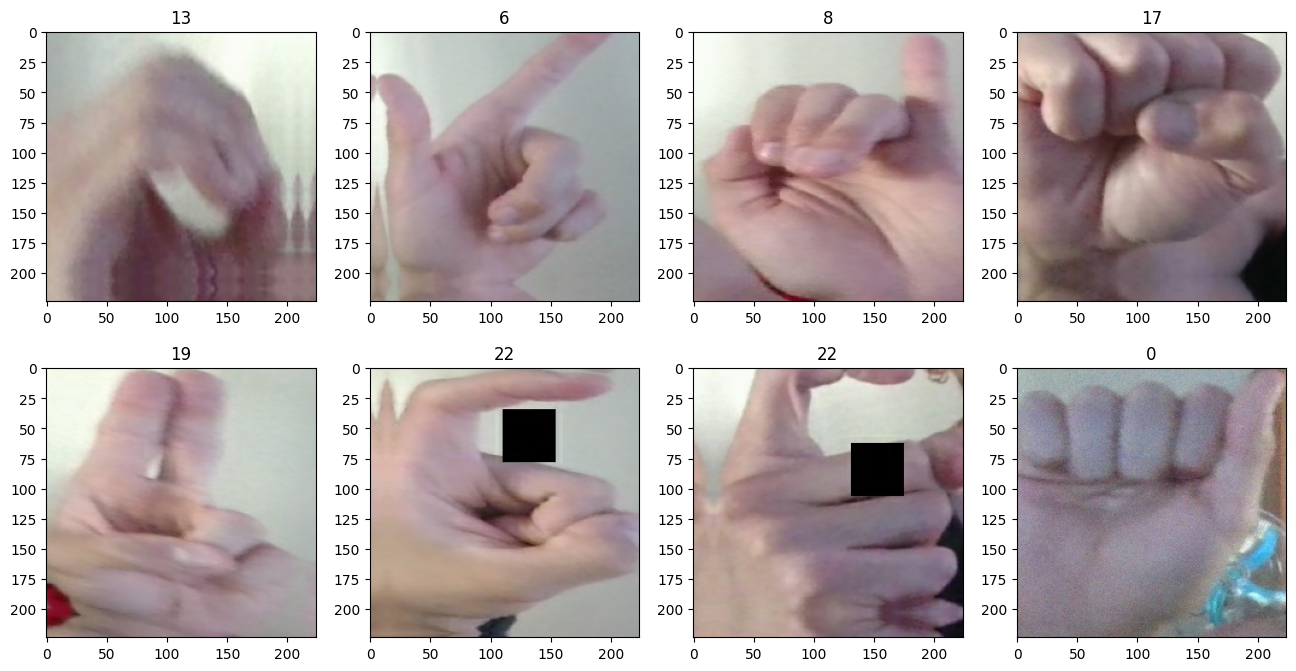

In [85]:
batch = data_iterator.next()

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(16,8))
ax = ax.flatten() 

for idx, img in enumerate(batch[0][:8]):
    ax[idx].imshow(img.astype(int))
    ax[idx].set_title(batch[1][idx])

2025-06-25 11:20:08.489447: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


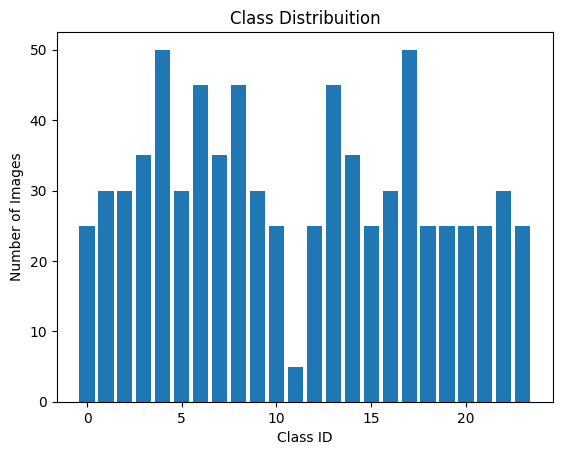

In [6]:
all_labels = []

for _, labels in dataset_raw:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

# Plot labels distribuition
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribuition")
plt.show()